# ContrailWatch evaluation dataset

The ContrailWatch evaluation dataset included in ContrailBench provides a gridded dataset of persistent contrail regions inferred from geostationary satellite imagery based on [ContrailWatch](https://developers.google.com/contrails/v1/ContrailWatch-description) flight attributions. This dataset is used to calculate forecast hit rates in ContrailBench benchmarks.

The ContrailWatch evaluation dataset is available alongside other evaluation datasets in a public cloud bucket (`gs://contrailbench-public-data`). This notebook shows
1. How to load ContrailWatch evaluation data using Pandas
2. How to interpret the contents of the ContrailWatch evaluation dataset
3. How to use the ContrailWatch evaluation dataset to compute ContrailBench hit rate metrics

In [2]:
import datetime
import os

import aiohttp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Loading ContrailWatch evaluation data

ContrailWatch evaluation data is sharded by time (one file per hour) and altitude (one file per flight level). Coverage for each ContrailBench release cycle is as follows:

| Release | Times | Altitudes| GCS path |
| --- | --- | --- | --- |
| V1 | Jan-Dec 2024 | FL270-440 | `gs://contrail-bench-public-data/V1/contrailwatch` |

Because gridded ContrailWatch data is relatively sparse, the dataset is stored as parquet files with one row for each grid cell with non-zero flight distance. These files can be read directly from GCS with Pandas.

> **Warning**: be very careful about timezone-naive datetimes when using ContrailBench evaluation datasets. Python's datetime module [assumes that naive datetimes represent local time](https://docs.python.org/3/library/datetime.html#datetime.datetime.timestamp), which affects the POSIX timestamp returned by `datetime.timestamp()`.

In [5]:
gcs_path = "gs://contrailbench-public-data/V1/contrailwatch"
time = datetime.datetime(2024, 6, 1, 0, tzinfo=datetime.UTC)
flight_level = 350

df = pd.read_parquet(f"{gcs_path}/{int(time.timestamp())}_{flight_level}.pq")
df

,longitude,latitude,attributed_flight_distance
0,-129.50,47.25,7545.800693
1,-129.25,47.00,32728.235804
2,-129.25,47.25,7547.689337
3,-129.00,46.50,11325.993957
4,-129.00,46.75,30426.549121
...,...,...,...
141,-52.25,44.75,21526.430866
142,-52.00,44.75,16140.115364
143,-52.00,45.00,2689.519933
144,-51.75,45.00,18823.657506


## Interpretation

Rows of the dataset provide lengths of attributed flight segments (in meters) aggregated on a spatiotemporal grid with 0.25 degree horizontal resolution. Horizontal bounds are from -180 degrees to 179.75 degrees longitude and -80 degrees to 80 degrees latitude. Each grid cell includes the total attributed flight distance

1. within 0.125 degrees latitude and longitude of the provided latitude and longitude coordinates,
2. within 250 vertical ft of the target flight level, and
3. within 30 minutes of the target time

Grid cells without any ContrailWatch attributions are omitted from the dataset to reduce data volume. If necessary, omitted grid cells can be restored using xarray:

In [6]:
all_lons = np.arange(-180.0, 180.0, 0.25)
all_lats = np.arange(-80, 80.25, 0.25)
ds = df.set_index(["longitude", "latitude"]).to_xarray().fillna(0.0)
ds = ds.reindex(longitude=all_lons, latitude=all_lats, fill_value=0.0)
ds

<xarray.Dataset> Size: 7MB
Dimensions:                     (longitude: 1440, latitude: 641)
Coordinates:
  * longitude                   (longitude) float64 12kB -180.0 -179.8 ... 179.8
  * latitude                    (latitude) float64 5kB -80.0 -79.75 ... 80.0
Data variables:
    attributed_flight_distance  (longitude, latitude) float64 7MB 0.0 ... 0.0

As of the V1 ContrailBench release, ContrailWatch flight attributions are limited to a region around the continental US. Coverage will likely expand in the future.

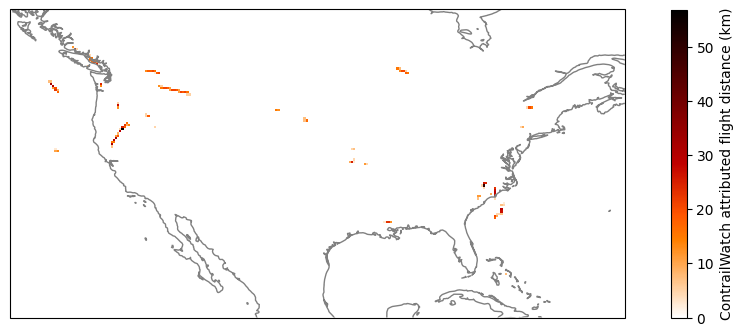

In [14]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
im = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    ds["attributed_flight_distance"].T / 1e3,
    shading="nearest",
    cmap="gist_heat_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, ax=ax, label="ContrailWatch attributed flight distance (km)")
ax.set_extent([-134, -63, 20, 50])
ax.coastlines(color="gray");

## Use in ContrailBench metrics

The ContrailBench evaluation dataset is used in PCR benchmarks to calculate forecast hit rates, a proxy for the effectiveness of avoidance.

This notebook uses the Contrails.org forecast for an example calculation. See the [Contrails.org example notebook](contrails-org.ipynb) for details about accessing and preprocessing the Contrails.org forecast.

In [15]:
url = "https://api.contrails.org/v1/grids"
params = {
    "aircraft_class": "default",
    "flight_level": str(flight_level),
    "time": time.strftime("%Y-%m-%dT%H"),
    "units": "ef_per_m",
}
headers = {"x-api-key": os.environ["CONTRAILS_API_KEY"]}

async with (
    aiohttp.ClientSession(raise_for_status=True) as session,
    session.get(url, params=params, headers=headers) as resp,
):
    content = await resp.read()

with open("forecast.nc", "wb") as f:
    f.write(content)
ds = xr.open_dataset("forecast.nc")

ds["pcr"] = ds["ef_per_m"] != 0
processed = ds[["pcr"]]

Forecast hit rates can be calculated using some xarray indexing tricks. This notebook computes hit rates treating all grid cells with non-zero `attributed_flight_distance` as observed PCRs and weighting grid cells by area, consistent with ContrailBench benchmarks.

In [16]:
target_lon = xr.DataArray(df["longitude"].loc[df["attributed_flight_distance"] > 0], dims="row")
target_lat = xr.DataArray(df["latitude"].loc[df["attributed_flight_distance"] > 0], dims="row")
area = xr.DataArray(
    np.cos(np.deg2rad(df["latitude"].loc[df["attributed_flight_distance"] > 0])), dims="row"
)

pcr = processed["pcr"].sel(longitude=target_lon, latitude=target_lat)
fcst_area = area.where(pcr).sum().item()
tot_area = area.sum().item()

print(f"Forecast hit rate: {fcst_area / tot_area:.3f}")

Forecast hit rate: 0.539
